# Autorefine Experiment Analysis

Analysis of autonomous throughput-optimization results from `results.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, decode_throughput, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["decode_throughput"] = pd.to_numeric(df["decode_throughput"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 10
Columns: ['commit', 'decode_throughput', 'memory_gb', 'status', 'description']


,commit,decode_throughput,memory_gb,status,description
0,e51e593,7626.00,20.4,KEEP,"baseline (max_num_seqs=512, max_num_batched_to..."
1,3d9b4fe,10349.22,20.6,KEEP,max_num_seqs=768 (+35.7% vs baseline)
2,1c21d0a,10039.55,20.6,DISCARD,max_num_seqs=1024 (preemption overhead hurts)
3,e8efd71,10967.82,20.5,KEEP,max_num_batched_tokens=32768 (+6.0% over exp1)
4,4a9db1b,11037.69,20.6,KEEP,max_num_batched_tokens=65536 (marginal +0.6%)
5,9968734,10988.24,21.8,DISCARD,"gpu_memory_utilization=0.95 (more memory, slig..."
6,4d9c161,10888.82,20.6,DISCARD,"finer graph ladder [1..8 step 1, 10,12,14,16, ..."
7,dbdef93,10651.80,19.0,DISCARD,chunked prefill cap 4096 tok/step (lower memor...
8,64e88c3,0.00,0.0,CRASH,kvcache_block_size=512 — BUG: Sequence.block_s...
9,0329b99,10993.02,20.6,DISCARD,CUDA graph max_bs+eager threshold 512→768 (cap...


In [2]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep    = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash   = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    5
KEEP       4
CRASH      1

Keep rate: 4/9 = 44.4%


In [3]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    tput = row["decode_throughput"]
    desc = row["description"]
    print(f"  #{i:3d}  throughput={tput:.2f} tok/s  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (4 total):

  #  0  throughput=7626.00 tok/s  mem=20.4GB  baseline (max_num_seqs=512, max_num_batched_tokens=16384, block_size=256, gpu_mem=0.9)
  #  1  throughput=10349.22 tok/s  mem=20.6GB  max_num_seqs=768 (+35.7% vs baseline)
  #  3  throughput=10967.82 tok/s  mem=20.5GB  max_num_batched_tokens=32768 (+6.0% over exp1)
  #  4  throughput=11037.69 tok/s  mem=20.6GB  max_num_batched_tokens=65536 (marginal +0.6%)


## Decode Throughput Over Time

Track how the best (kept) decode throughput evolves as experiments progress.
The running maximum shows the "frontier" — the best result achieved so far.

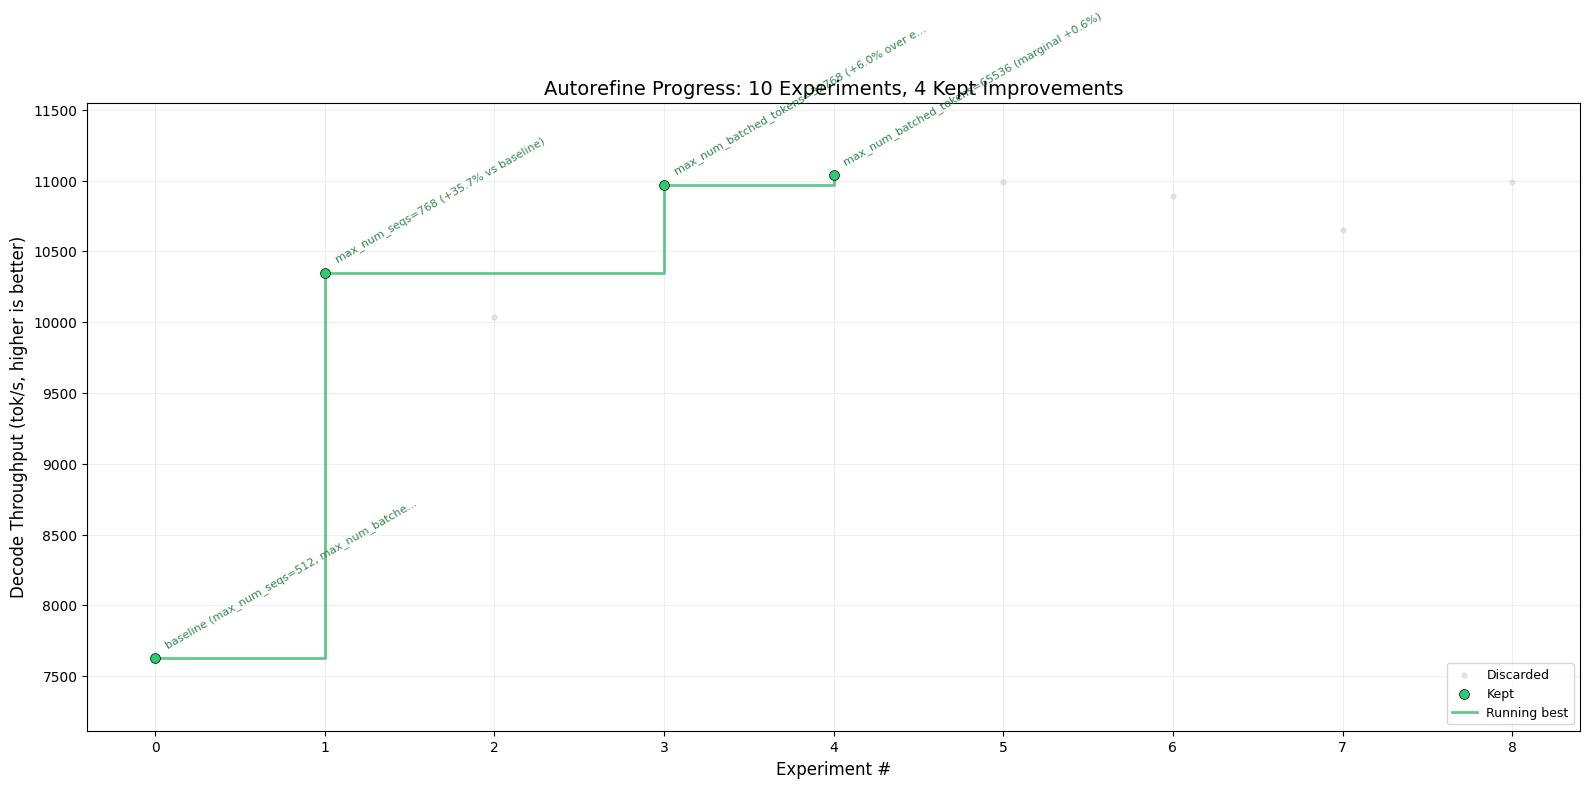

Saved to progress.png


In [4]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_tput = valid.loc[0, "decode_throughput"]

# Only plot points at or above baseline (the interesting region)
above = valid[valid["decode_throughput"] >= baseline_tput * 0.9995]

# Plot discarded as faint background dots
disc = above[above["status"] == "DISCARD"]
ax.scatter(disc.index, disc["decode_throughput"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = above[above["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["decode_throughput"],
           c="#2ecc71", s=50, zorder=4, label="Kept",
           edgecolors="black", linewidths=0.5)

# Running maximum step line
kept_mask = valid["status"] == "KEEP"
kept_idx  = valid.index[kept_mask]
kept_tput = valid.loc[kept_mask, "decode_throughput"]
running_max = kept_tput.cummax()
ax.step(kept_idx, running_max, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, tput in zip(kept_idx, kept_tput):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."
    ax.annotate(desc, (idx, tput),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept  = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Decode Throughput (tok/s, higher is better)", fontsize=12)
ax.set_title(
    f"Autorefine Progress: {n_total} Experiments, {n_kept} Kept Improvements",
    fontsize=14,
)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: just below baseline to just above best
best_tput = kept_tput.max()
margin = (best_tput - baseline_tput) * 0.15
ax.set_ylim(baseline_tput - margin, best_tput + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")

## Summary Statistics

In [5]:
kept = df[df["status"] == "KEEP"].copy()
baseline_tput = df.iloc[0]["decode_throughput"]
best_tput     = kept["decode_throughput"].max()
best_row      = kept.loc[kept["decode_throughput"].idxmax()]

print(f"Baseline throughput:  {baseline_tput:.2f} tok/s")
print(f"Best throughput:      {best_tput:.2f} tok/s")
print(f"Total improvement:    +{best_tput - baseline_tput:.2f} tok/s "
      f"({(best_tput - baseline_tput) / baseline_tput * 100:.2f}%)")
print(f"Best experiment:      {best_row['description']}")
print()

print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for _, row in kept_sorted.iterrows():
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: throughput={row['decode_throughput']:.2f} tok/s  {desc}")

Baseline throughput:  7626.00 tok/s
Best throughput:      11037.69 tok/s
Total improvement:    +3411.69 tok/s (44.74%)
Best experiment:      max_num_batched_tokens=65536 (marginal +0.6%)

Cumulative effort per improvement:
  Experiment #  0: throughput=7626.00 tok/s  baseline (max_num_seqs=512, max_num_batched_tokens=16384, block_size=256, gpu_mem=0.9)
  Experiment #  1: throughput=10349.22 tok/s  max_num_seqs=768 (+35.7% vs baseline)
  Experiment #  3: throughput=10967.82 tok/s  max_num_batched_tokens=32768 (+6.0% over exp1)
  Experiment #  4: throughput=11037.69 tok/s  max_num_batched_tokens=65536 (marginal +0.6%)


## Top Hits (Kept Experiments by Improvement)

In [6]:
# Delta = improvement over the previous kept experiment
kept = df[df["status"] == "KEEP"].copy()
kept["prev_tput"] = kept["decode_throughput"].shift(1)
kept["delta"]     = kept["decode_throughput"] - kept["prev_tput"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta (tok/s)':>14}  {'Throughput':>12}  Description")
print("-" * 90)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+14.2f}  {row['decode_throughput']:12.2f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+14.2f}  {'':>12}  TOTAL improvement over baseline")

Rank   Delta (tok/s)    Throughput  Description
------------------------------------------------------------------------------------------
   1        +2723.22      10349.22  max_num_seqs=768 (+35.7% vs baseline)
   2         +618.60      10967.82  max_num_batched_tokens=32768 (+6.0% over exp1)
   3          +69.87      11037.69  max_num_batched_tokens=65536 (marginal +0.6%)

            +3411.69                TOTAL improvement over baseline


## Memory vs Throughput Scatter

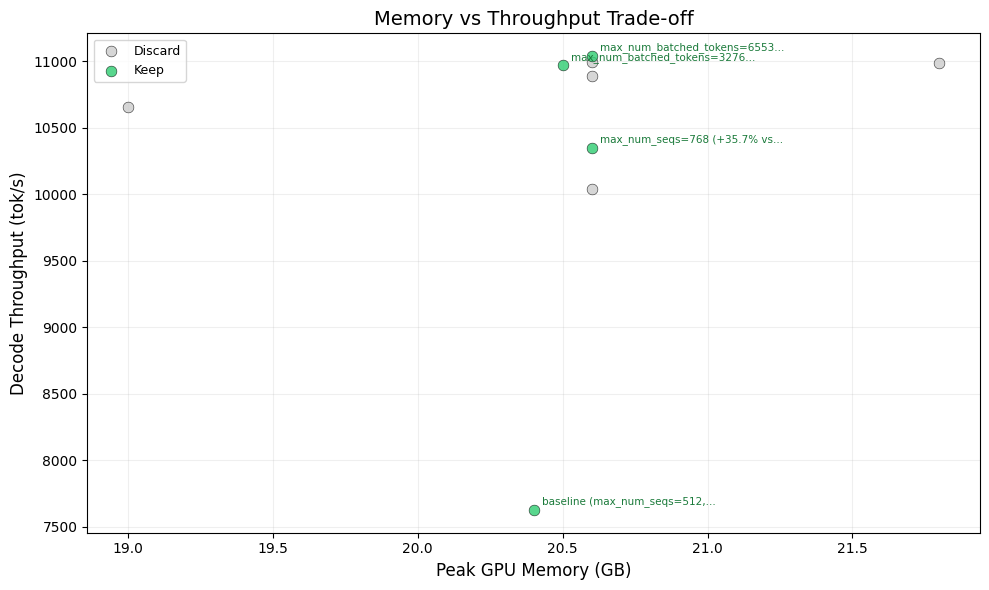

Saved to memory_vs_throughput.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

valid = df[df["status"] != "CRASH"].copy()

colors = {"KEEP": "#2ecc71", "DISCARD": "#cccccc"}
for status, grp in valid.groupby("status"):
    ax.scatter(
        grp["memory_gb"], grp["decode_throughput"],
        c=colors.get(status, "gray"),
        s=60, alpha=0.8, label=status.capitalize(),
        edgecolors="black", linewidths=0.4, zorder=3,
    )

# Annotate kept points
kept = valid[valid["status"] == "KEEP"]
for _, row in kept.iterrows():
    desc = str(row["description"]).strip()
    if len(desc) > 30:
        desc = desc[:27] + "..."
    ax.annotate(desc, (row["memory_gb"], row["decode_throughput"]),
                textcoords="offset points", xytext=(6, 4),
                fontsize=7.5, color="#1a7a3a")

ax.set_xlabel("Peak GPU Memory (GB)", fontsize=12)
ax.set_ylabel("Decode Throughput (tok/s)", fontsize=12)
ax.set_title("Memory vs Throughput Trade-off", fontsize=14)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("memory_vs_throughput.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to memory_vs_throughput.png")